# 📊 Notebook 02 — Exploration des données d'entraînement

Ce notebook analyse les logs générés par `train_dqn.py`.

**Prérequis :** avoir lancé `train_dqn.py` au moins une fois pour générer `results/training_log.csv`

**Objectifs :**
- Charger et inspecter le fichier de logs
- Visualiser la progression de l'apprentissage
- Comparer la baseline aléatoire vs le modèle entraîné
- Identifier les phases Exploration / Exploitation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

LOG_PATH = '../results/training_log.csv'

if not os.path.exists(LOG_PATH):
    print('⚠️  Fichier de logs introuvable.')
    print('Lance d\'abord : python src/train_dqn.py')
else:
    df = pd.read_csv(LOG_PATH)
    print(f'✅ {len(df)} épisodes chargés.')
    print(f'Colonnes : {list(df.columns)}')
    df.head(10)

✅ 6274 épisodes chargés.
Colonnes : ['timestep', 'episode', 'reward', 'length', 'mean_reward_10ep']


## 1. Résumé statistique

In [2]:
print('='*45)
print('      RÉSUMÉ DE L\'ENTRAÎNEMENT')
print('='*45)
print(f'  Épisodes total           : {len(df)}')
print(f'  Timesteps total          : {df["timestep"].max():,}')
print(f'  Récompense max           : {df["reward"].max():.2f}')
print(f'  Récompense min           : {df["reward"].min():.2f}')
print(f'  Récompense moyenne       : {df["reward"].mean():.2f}')
print(f'  Moy. 10 derniers épisodes: {df["mean_reward_10ep"].iloc[-1]:.2f}')
print(f'  Durée moy. épisode (pas) : {df["length"].mean():.0f}')
print('='*45)

      RÉSUMÉ DE L'ENTRAÎNEMENT
  Épisodes total           : 6274
  Timesteps total          : 99,984
  Récompense max           : 29.84
  Récompense min           : 1.02
  Récompense moyenne       : 13.48
  Moy. 10 derniers épisodes: 22.68
  Durée moy. épisode (pas) : 16


## 2. Courbe d'apprentissage complète

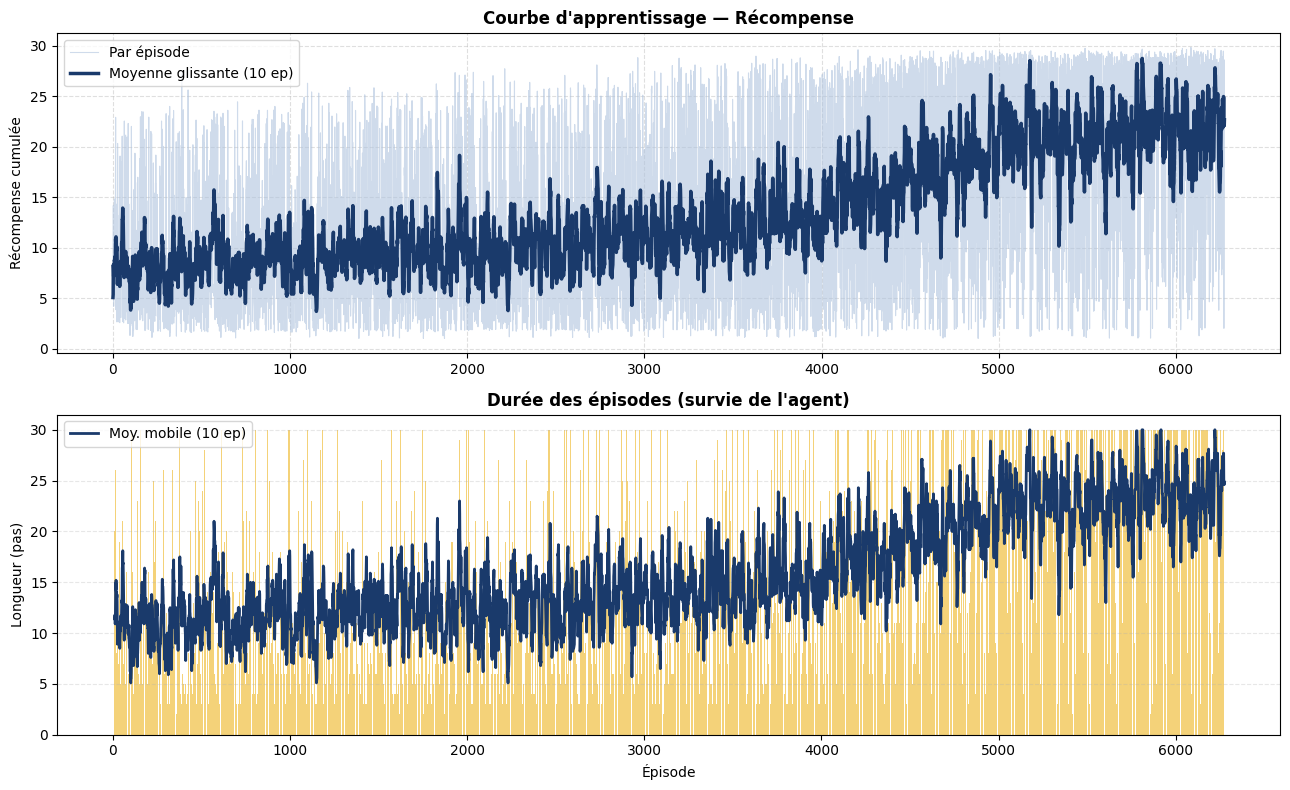

✅ Graphique sauvegardé.


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# --- Graphique 1 : Récompense ---
ax1 = axes[0]
ax1.plot(df['episode'], df['reward'], color='#b0c4de', linewidth=0.8, alpha=0.6, label='Par épisode')
ax1.plot(df['episode'], df['mean_reward_10ep'], color='#1a3a6b', linewidth=2.5, label='Moyenne glissante (10 ep)')
ax1.set_title('Courbe d\'apprentissage — Récompense', fontweight='bold')
ax1.set_ylabel('Récompense cumulée')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

# --- Graphique 2 : Longueur des épisodes ---
ax2 = axes[1]
ax2.bar(df['episode'], df['length'], color='#f0c040', alpha=0.7, width=0.9)
ax2.plot(df['episode'], df['length'].rolling(10).mean(), color='#1a3a6b', linewidth=2, label='Moy. mobile (10 ep)')
ax2.set_title('Durée des épisodes (survie de l\'agent)', fontweight='bold')
ax2.set_xlabel('Épisode')
ax2.set_ylabel('Longueur (pas)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/apprentissage_complet.png', dpi=150)
plt.show()
print('✅ Graphique sauvegardé.')

## 3. Phases Exploration vs Exploitation

Le DQN commence par **explorer** (actions aléatoires) puis **exploite** ce qu'il a appris. On peut visualiser cette transition en divisant les épisodes en tiers.

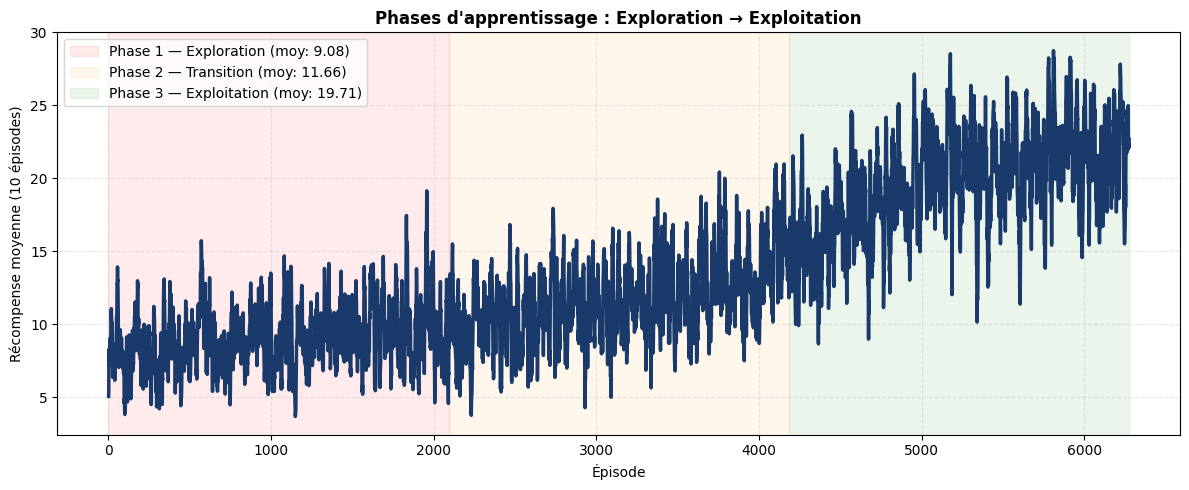

In [4]:
n = len(df)
third = n // 3

phase1 = df.iloc[:third]['reward']
phase2 = df.iloc[third:2*third]['reward']
phase3 = df.iloc[2*third:]['reward']

fig, ax = plt.subplots(figsize=(12, 5))

ax.axvspan(0, third, alpha=0.08, color='red', label=f'Phase 1 — Exploration (moy: {phase1.mean():.2f})')
ax.axvspan(third, 2*third, alpha=0.08, color='orange', label=f'Phase 2 — Transition (moy: {phase2.mean():.2f})')
ax.axvspan(2*third, n, alpha=0.08, color='green', label=f'Phase 3 — Exploitation (moy: {phase3.mean():.2f})')

ax.plot(df['episode'], df['mean_reward_10ep'], color='#1a3a6b', linewidth=2.5)
ax.set_title('Phases d\'apprentissage : Exploration → Exploitation', fontweight='bold')
ax.set_xlabel('Épisode')
ax.set_ylabel('Récompense moyenne (10 épisodes)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/phases_apprentissage.png', dpi=150)
plt.show()

## 4. Distribution des récompenses (début vs fin d'entraînement)

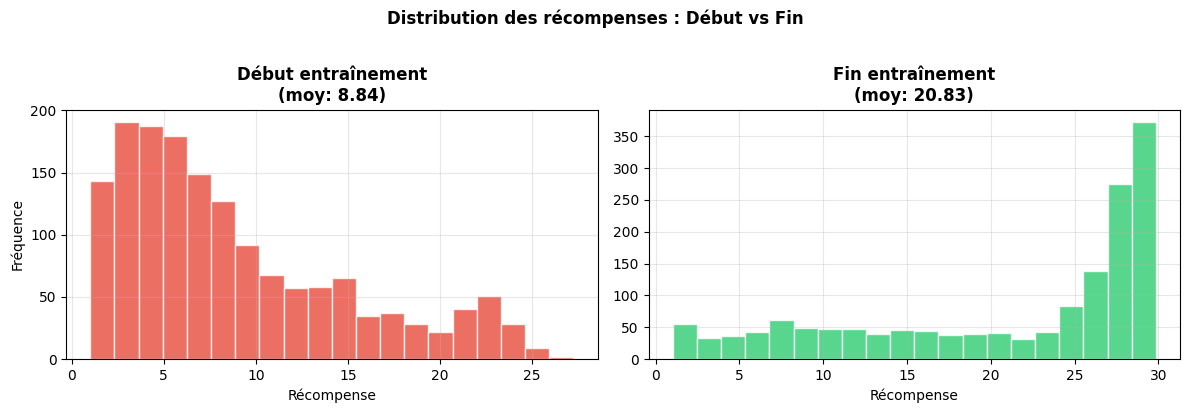


📈 Amélioration : 8.84 → 20.83 (+11.99)


In [5]:
debut = df.head(n // 4)['reward']
fin = df.tail(n // 4)['reward']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(debut, bins=20, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Début entraînement\n(moy: {debut.mean():.2f})', fontweight='bold')
axes[0].set_xlabel('Récompense')
axes[0].set_ylabel('Fréquence')
axes[0].grid(True, alpha=0.3)

axes[1].hist(fin, bins=20, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].set_title(f'Fin entraînement\n(moy: {fin.mean():.2f})', fontweight='bold')
axes[1].set_xlabel('Récompense')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Distribution des récompenses : Début vs Fin', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/distribution_recompenses.png', dpi=150)
plt.show()
print(f'\n📈 Amélioration : {debut.mean():.2f} → {fin.mean():.2f} (+{fin.mean()-debut.mean():.2f})')